In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from scipy.stats import gaussian_kde
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set font and style
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

In [2]:
# 2. Load Data
df = pd.read_csv('../HNRNPC/train.tsv', sep='\t')
print(f"Data shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Data shape: (2400, 4)
Label distribution:
label
0    1220
1    1180
Name: count, dtype: int64


In [3]:
# 3. Data Preprocessing
# Prepare data for visualization
all_3mer_codes_0 = []
all_3mer_codes_1 = []
all_structures_0 = []
all_structures_1 = []
all_probabilities_0 = []
all_probabilities_1 = []

# Create all possible 3-mer mappings (4^3 = 64 types)
bases = ['A', 'C', 'G', 'U']
all_kmers = [''.join(comb) for comb in product(bases, repeat=3)]
kmer_to_code = {kmer: idx for idx, kmer in enumerate(all_kmers)}

print("Processing data...")

for idx, row in df.iterrows():
    sequence = row['sequence']
    structure = list(map(int, row['structure'].split(',')))
    probabilities = list(map(float, row['pairing_probabilities'].split(',')))
    label = row['label']
    
    # Extract 3-mer codes
    kmers = [sequence[i:i+3] for i in range(len(sequence)-2)]
    kmer_codes = [kmer_to_code[kmer] for kmer in kmers if kmer in kmer_to_code]
    
    # Extract structure codes
    structure_codes = structure
    
    # Extract probability values (rounded to 3 decimal places)
    prob_values = [round(p, 3) for p in probabilities]
    
    # Group by label
    if label == 0:
        all_3mer_codes_0.extend(kmer_codes)
        all_structures_0.extend(structure_codes)
        all_probabilities_0.extend(prob_values)
    else:
        all_3mer_codes_1.extend(kmer_codes)
        all_structures_1.extend(structure_codes)
        all_probabilities_1.extend(prob_values)

print(f"Label 0: {len(all_3mer_codes_0)} 3-mer codes, {len(all_structures_0)} structure codes, {len(all_probabilities_0)} probability values")
print(f"Label 1: {len(all_3mer_codes_1)} 3-mer codes, {len(all_structures_1)} structure codes, {len(all_probabilities_1)} probability values")

Processing data...
Label 0: 120780 3-mer codes, 123220 structure codes, 123220 probability values
Label 1: 116820 3-mer codes, 119180 structure codes, 119180 probability values


In [4]:
# 4. Define Visualization Functions
# Color settings
colors = ['#1f77b4', '#ff7f0e']  # Blue and orange

def plot_discrete_distribution(ax, data_0, data_1, color_0, color_1, xlabel, categories):
    # Calculate frequency
    freq_0 = [data_0.count(cat) / len(data_0) if len(data_0) > 0 else 0 for cat in categories]
    freq_1 = [data_1.count(cat) / len(data_1) if len(data_1) > 0 else 0 for cat in categories]
    
    # Set the parameters of the bar chart
    bar_width = 0.35
    x_pos = np.arange(len(categories))
    
    # Draw a bar chart
    bars0 = ax.bar(x_pos - bar_width/2, freq_0, width=bar_width, alpha=0.7, 
                   color=color_0, label='Label 0')
    bars1 = ax.bar(x_pos + bar_width/2, freq_1, width=bar_width, alpha=0.7, 
                   color=color_1, label='Label 1')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density (Frequency)')

    if len(categories) > 20:
        step = max(1, len(categories) // 16) 
        visible_ticks = list(range(0, len(categories), step))
        ax.set_xticks(visible_ticks)
        ax.set_xticklabels([str(categories[i]) for i in visible_ticks], 
                          rotation=45, ha='right')
        
        ax.grid(True, alpha=0.3, axis='x')
    else:
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(cat) for cat in categories])
    
    ax.legend()
    return bars0, bars1

# Function for continuous data KDE
def plot_continuous_kde(ax, data_0, data_1, color_0, color_1, xlabel):
    """Plot kernel density estimation for continuous data"""
    # Ensure data is 1D
    data_0 = np.array(data_0).flatten()
    data_1 = np.array(data_1).flatten()
    
    # Calculate kernel density estimation
    if len(data_0) > 1:
        kde_0 = gaussian_kde(data_0)
        x_min_0, x_max_0 = data_0.min(), data_0.max()
        x_0 = np.linspace(x_min_0, x_max_0, 100)
        y_0 = kde_0(x_0)
        ax.plot(x_0, y_0, color=color_0, linewidth=2, label='Label 0')
        ax.fill_between(x_0, y_0, alpha=0.3, color=color_0)
    
    if len(data_1) > 1:
        kde_1 = gaussian_kde(data_1)
        x_min_1, x_max_1 = data_1.min(), data_1.max()
        x_1 = np.linspace(x_min_1, x_max_1, 100)
        y_1 = kde_1(x_1)
        ax.plot(x_1, y_1, color=color_1, linewidth=2, label='Label 1')
        ax.fill_between(x_1, y_1, alpha=0.3, color=color_1)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

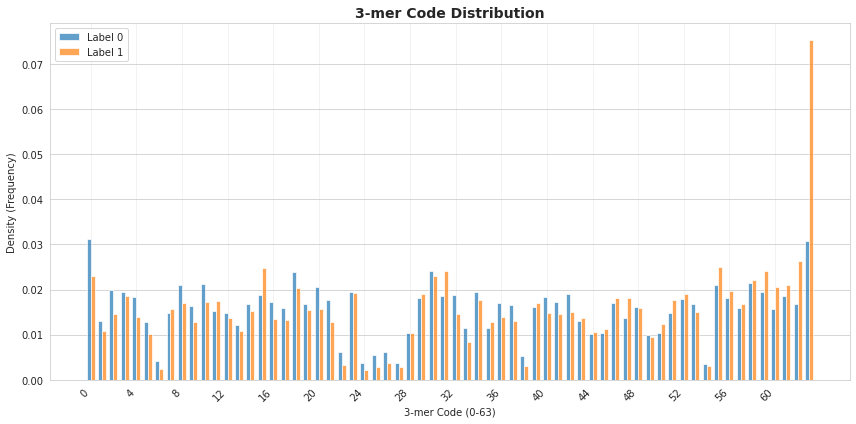

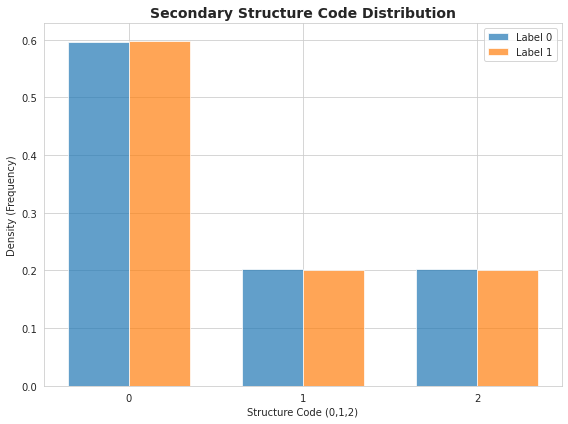

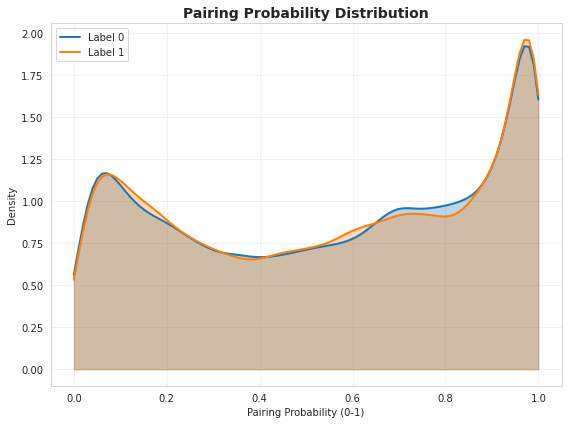

In [5]:
# 5. Visualization
# Create and save 3-mer codes distribution plot
fig1, ax1 = plt.subplots(figsize=(12, 6))
plot_discrete_distribution(ax1, all_3mer_codes_0, all_3mer_codes_1, 
                         colors[0], colors[1], '3-mer Code (0-63)', 
                         categories=list(range(64)))
ax1.set_title('3-mer Code Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('PNG/train_3mer_distribution.png', dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# Create and save secondary structure distribution plot
fig2, ax2 = plt.subplots(figsize=(8, 6))
plot_discrete_distribution(ax2, all_structures_0, all_structures_1, 
                         colors[0], colors[1], 'Structure Code (0,1,2)', 
                         categories=[0, 1, 2])
ax2.set_title('Secondary Structure Code Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('PNG/train_structure_distribution.png', dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

# Create and save pairing probability distribution plot
fig3, ax3 = plt.subplots(figsize=(8, 6))
plot_continuous_kde(ax3, all_probabilities_0, all_probabilities_1, 
                   colors[0], colors[1], 'Pairing Probability (0-1)')
ax3.set_title('Pairing Probability Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('PNG/train_probability_distribution.png', dpi=600, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

In [6]:
# 6. Statistical Summary
# Get most frequent 3-mer codes
def get_top_kmers(codes, kmer_to_code, top_n=5):
    # Reverse mapping from code to kmer
    code_to_kmer = {v: k for k, v in kmer_to_code.items()}
    
    # Count frequencies
    counter = Counter(codes)
    
    # Get top N
    top_items = counter.most_common(top_n)
    
    # Convert to kmer strings
    return [(code_to_kmer[code], count) for code, count in top_items]

# Statistical summary
print("\n=== Statistical Summary ===")
print("3-mer Codes:")
print(f"  Label 0 - Total: {len(all_3mer_codes_0)}, Unique: {len(set(all_3mer_codes_0))}")
print(f"  Label 1 - Total: {len(all_3mer_codes_1)}, Unique: {len(set(all_3mer_codes_1))}")

# Find top 5 most frequent 3-mer codes for each label
top_0 = get_top_kmers(all_3mer_codes_0, kmer_to_code)
top_1 = get_top_kmers(all_3mer_codes_1, kmer_to_code)

print(f"  Label 0 - Top 5: {top_0}")
print(f"  Label 1 - Top 5: {top_1}")

print("\nSecondary Structure Codes:")
struct_counts_0 = [all_structures_0.count(i) for i in [0,1,2]]
struct_counts_1 = [all_structures_1.count(i) for i in [0,1,2]]
print(f"  Label 0 - 0: {struct_counts_0[0]}, 1: {struct_counts_0[1]}, 2: {struct_counts_0[2]}")
print(f"  Label 1 - 0: {struct_counts_1[0]}, 1: {struct_counts_1[1]}, 2: {struct_counts_1[2]}")

print("\nPairing Probabilities:")
print(f"  Label 0 - Mean: {np.mean(all_probabilities_0):.3f}, Std: {np.std(all_probabilities_0):.3f}")
print(f"  Label 1 - Mean: {np.mean(all_probabilities_1):.3f}, Std: {np.std(all_probabilities_1):.3f}")


=== Statistical Summary ===
3-mer Codes:
  Label 0 - Total: 120780, Unique: 64
  Label 1 - Total: 116820, Unique: 64
  Label 0 - Top 5: [('AAA', 3761), ('UUU', 3719), ('CUG', 2921), ('CAG', 2891), ('UGG', 2583)]
  Label 1 - Top 5: [('UUU', 8793), ('UUG', 3071), ('UCU', 2918), ('AUU', 2897), ('CUU', 2826)]

Secondary Structure Codes:
  Label 0 - 0: 73408, 1: 24906, 2: 24906
  Label 1 - 0: 71334, 1: 23923, 2: 23923

Pairing Probabilities:
  Label 0 - Mean: 0.557, Std: 0.327
  Label 1 - Mean: 0.556, Std: 0.327
